# Packages Installation

In [1]:
!pip uninstall numpy -y
!pip install "numpy<2"

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.8/15.8 MB 5.6 MB/s eta 0:00:03
   ----- ---------------------------------- 2.1/15.8 MB 5.9 MB/s eta 0:00:03
   ------- -------------------------------- 2.9/15.8 MB 5.1 MB/s eta 0:00:03
   --------- ------------------------------ 3.7/15.8 MB 4.5 MB/s eta 0:00:03
   ----------- ---------------------------- 4.5/15.8 MB 4.3 MB/s eta 0:00:03
   ------------- -------------------------- 5.2/15.8 MB 4.4 MB/s eta 0:00:03
   --------------- ------------------------ 6.3/15.8 MB 4.5 MB/s eta 0:00:03
   ------------------ --------------------- 7.3/15.8 MB 4.5 MB/s eta 0:00:02
   --------------------- ------------------ 8.7/15.8 MB 4.6 MB/s eta 0:00:02
   ------------------------ --------------- 9.7/15.8 MB 4.7 MB/s eta 0:00:02
   --------------------------- ------------ 11.0/15


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install wfdb pandas matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Import Dataset

In [1]:
import os
import pandas as pd
import wfdb
import numpy as np
import ast

# Base folder of unzipped data
BASE_PATH = "dataset"

# Load PTB-XL metadata
df = pd.read_csv(os.path.join(BASE_PATH, "ptbxl_database.csv"))
scp_df = pd.read_csv(os.path.join(BASE_PATH, "scp_statements.csv"), index_col=0)

# Load ECG Signals

In [2]:
# Filter diagnostic SCP codes
scp_df = scp_df[scp_df['diagnostic'] == 1]
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

# Map SCP codes to subclass names
def diagnostic_class(scp):
    scp_df
    res = set()
    for k in scp.keys():
        if k in scp_df.index:
            res.add(scp_df.loc[k].diagnostic_class)
    return list(res)
                    
df['scp_classes'] = df.scp_codes.apply(diagnostic_class)

In [3]:
df

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,scp_classes
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM]
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM]
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM]
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM]
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21832,21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,...,NaN,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr,[STTC]
21833,21834,20703.0,93.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,...,NaN,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,[NORM]
21834,21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,...,NaN,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr,[STTC]
21835,21836,8873.0,64.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-09 18:21:49,...,NaN,NaN,NaN,NaN,SVES,NaN,8,records100/21000/21836_lr,records500/21000/21836_hr,[NORM]


In [4]:
prioritas = ["MI", "STTC", "CD", "HYP", "NORM"]

def diagnostic_superclass(superclass_list):
    for kelas in prioritas:
        if kelas in superclass_list:
            return kelas
    return None

df["final_superclass"] = df["scp_classes"].apply(diagnostic_superclass)

class_counts = df["final_superclass"].value_counts()


In [5]:
df

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,scp_classes,final_superclass
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM],NORM
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM],NORM
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM],NORM
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM],NORM
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM],NORM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21832,21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,...,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr,[STTC],STTC
21833,21834,20703.0,93.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,...,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,[NORM],NORM
21834,21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,...,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr,[STTC],STTC
21835,21836,8873.0,64.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-09 18:21:49,...,NaN,NaN,NaN,SVES,NaN,8,records100/21000/21836_lr,records500/21000/21836_hr,[NORM],NORM


In [6]:
class_counts

final_superclass
NORM    9083
MI      5486
STTC    3905
CD      2418
HYP      538
Name: count, dtype: int64

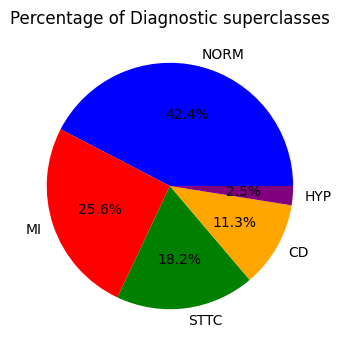

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=["blue", "red", "green", "orange", "purple"])
plt.title("Percentage of Diagnostic superclasses")
plt.show()

In [8]:
selected_classes = ['NORM', 'MI', 'HYP']
filtered_df = df[df['final_superclass'].apply(lambda x: any(cls == x for cls in selected_classes))].copy()

# Assign binary label: 0 = only NORM, 1 = has MI or HYP
def assign_binary_label(subclasses):
    if subclasses == 'NORM':
        return 0
    elif 'MI' in subclasses or 'HYP' in subclasses:
        return 1
    return None

filtered_df['label'] = filtered_df['final_superclass'].apply(assign_binary_label)

In [9]:
filtered_df

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,scp_classes,final_superclass,label
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM],NORM,0
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM],NORM,0
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM],NORM,0
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM],NORM,0
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM],NORM,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21829,21830,10520.0,86.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-05-28 07:53:21,...,NaN,NaN,NaN,NaN,1,records100/21000/21830_lr,records500/21000/21830_hr,[NORM],NORM,0
21830,21831,11905.0,55.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-28 12:49:25,...,NaN,NaN,NaN,NaN,9,records100/21000/21831_lr,records500/21000/21831_hr,[NORM],NORM,0
21833,21834,20703.0,93.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,...,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,[NORM],NORM,0
21835,21836,8873.0,64.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-09 18:21:49,...,NaN,NaN,SVES,NaN,8,records100/21000/21836_lr,records500/21000/21836_hr,[NORM],NORM,0


In [10]:
filtered_df['final_superclass'].value_counts()

final_superclass
NORM    9083
MI      5486
HYP      538
Name: count, dtype: int64

In [11]:
filtered_df.to_csv('filtered_dataset.csv', index=False)

In [14]:
def load_ptbxl_signal(filepath):
    record = wfdb.rdrecord(filepath)
    return record.p_signal, record.sig_name  # Shape: (time_steps, 12) for 12-lead

# Load signals
signals = []
ids = []
labels = []
leads_names = []

for idx, row in filtered_df.iterrows():
    ecg_path = row['filename_hr']
    path = os.path.join(BASE_PATH, ecg_path)
    
    try:
        sig, lead_name = load_ptbxl_signal(path)
        signals.append(sig)
        leads_names.append(lead_name)
        ids.append(row['ecg_id'])
        labels.append(row['label'])
    except Exception as e:
        print(f"Error loading {path}: {e}")

# Data Preprocessing

In [15]:
from scipy.signal import butter, filtfilt
import numpy as np

def highpass_filter(signal, fs=500, cutoff=0.5, order=3):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, signal, axis=0)

def normalize_signal(signal):
    return (signal - np.mean(signal, axis=0)) / np.std(signal, axis=0)

def preprocess_signal(signal):
    signal = highpass_filter(signal)
    signal = normalize_signal(signal)
    return signal

In [16]:
preprocessed_signals = preprocess_signal(signals)

In [17]:
X = np.array(preprocessed_signals)  # shape: (n_samples, 5000, 12)
y = np.array(labels)

print("Loaded ECG signals shape:", X.shape)
print("Binary labels shape:", y.shape)
print("Label counts:", np.unique(y, return_counts=True))

Loaded ECG signals shape: (15107, 5000, 12)
Binary labels shape: (15107,)
Label counts: (array([0, 1]), array([9083, 6024]))


In [20]:
np.savez("ecg_dataset.npz", x=X, y=y)

# Plot Data

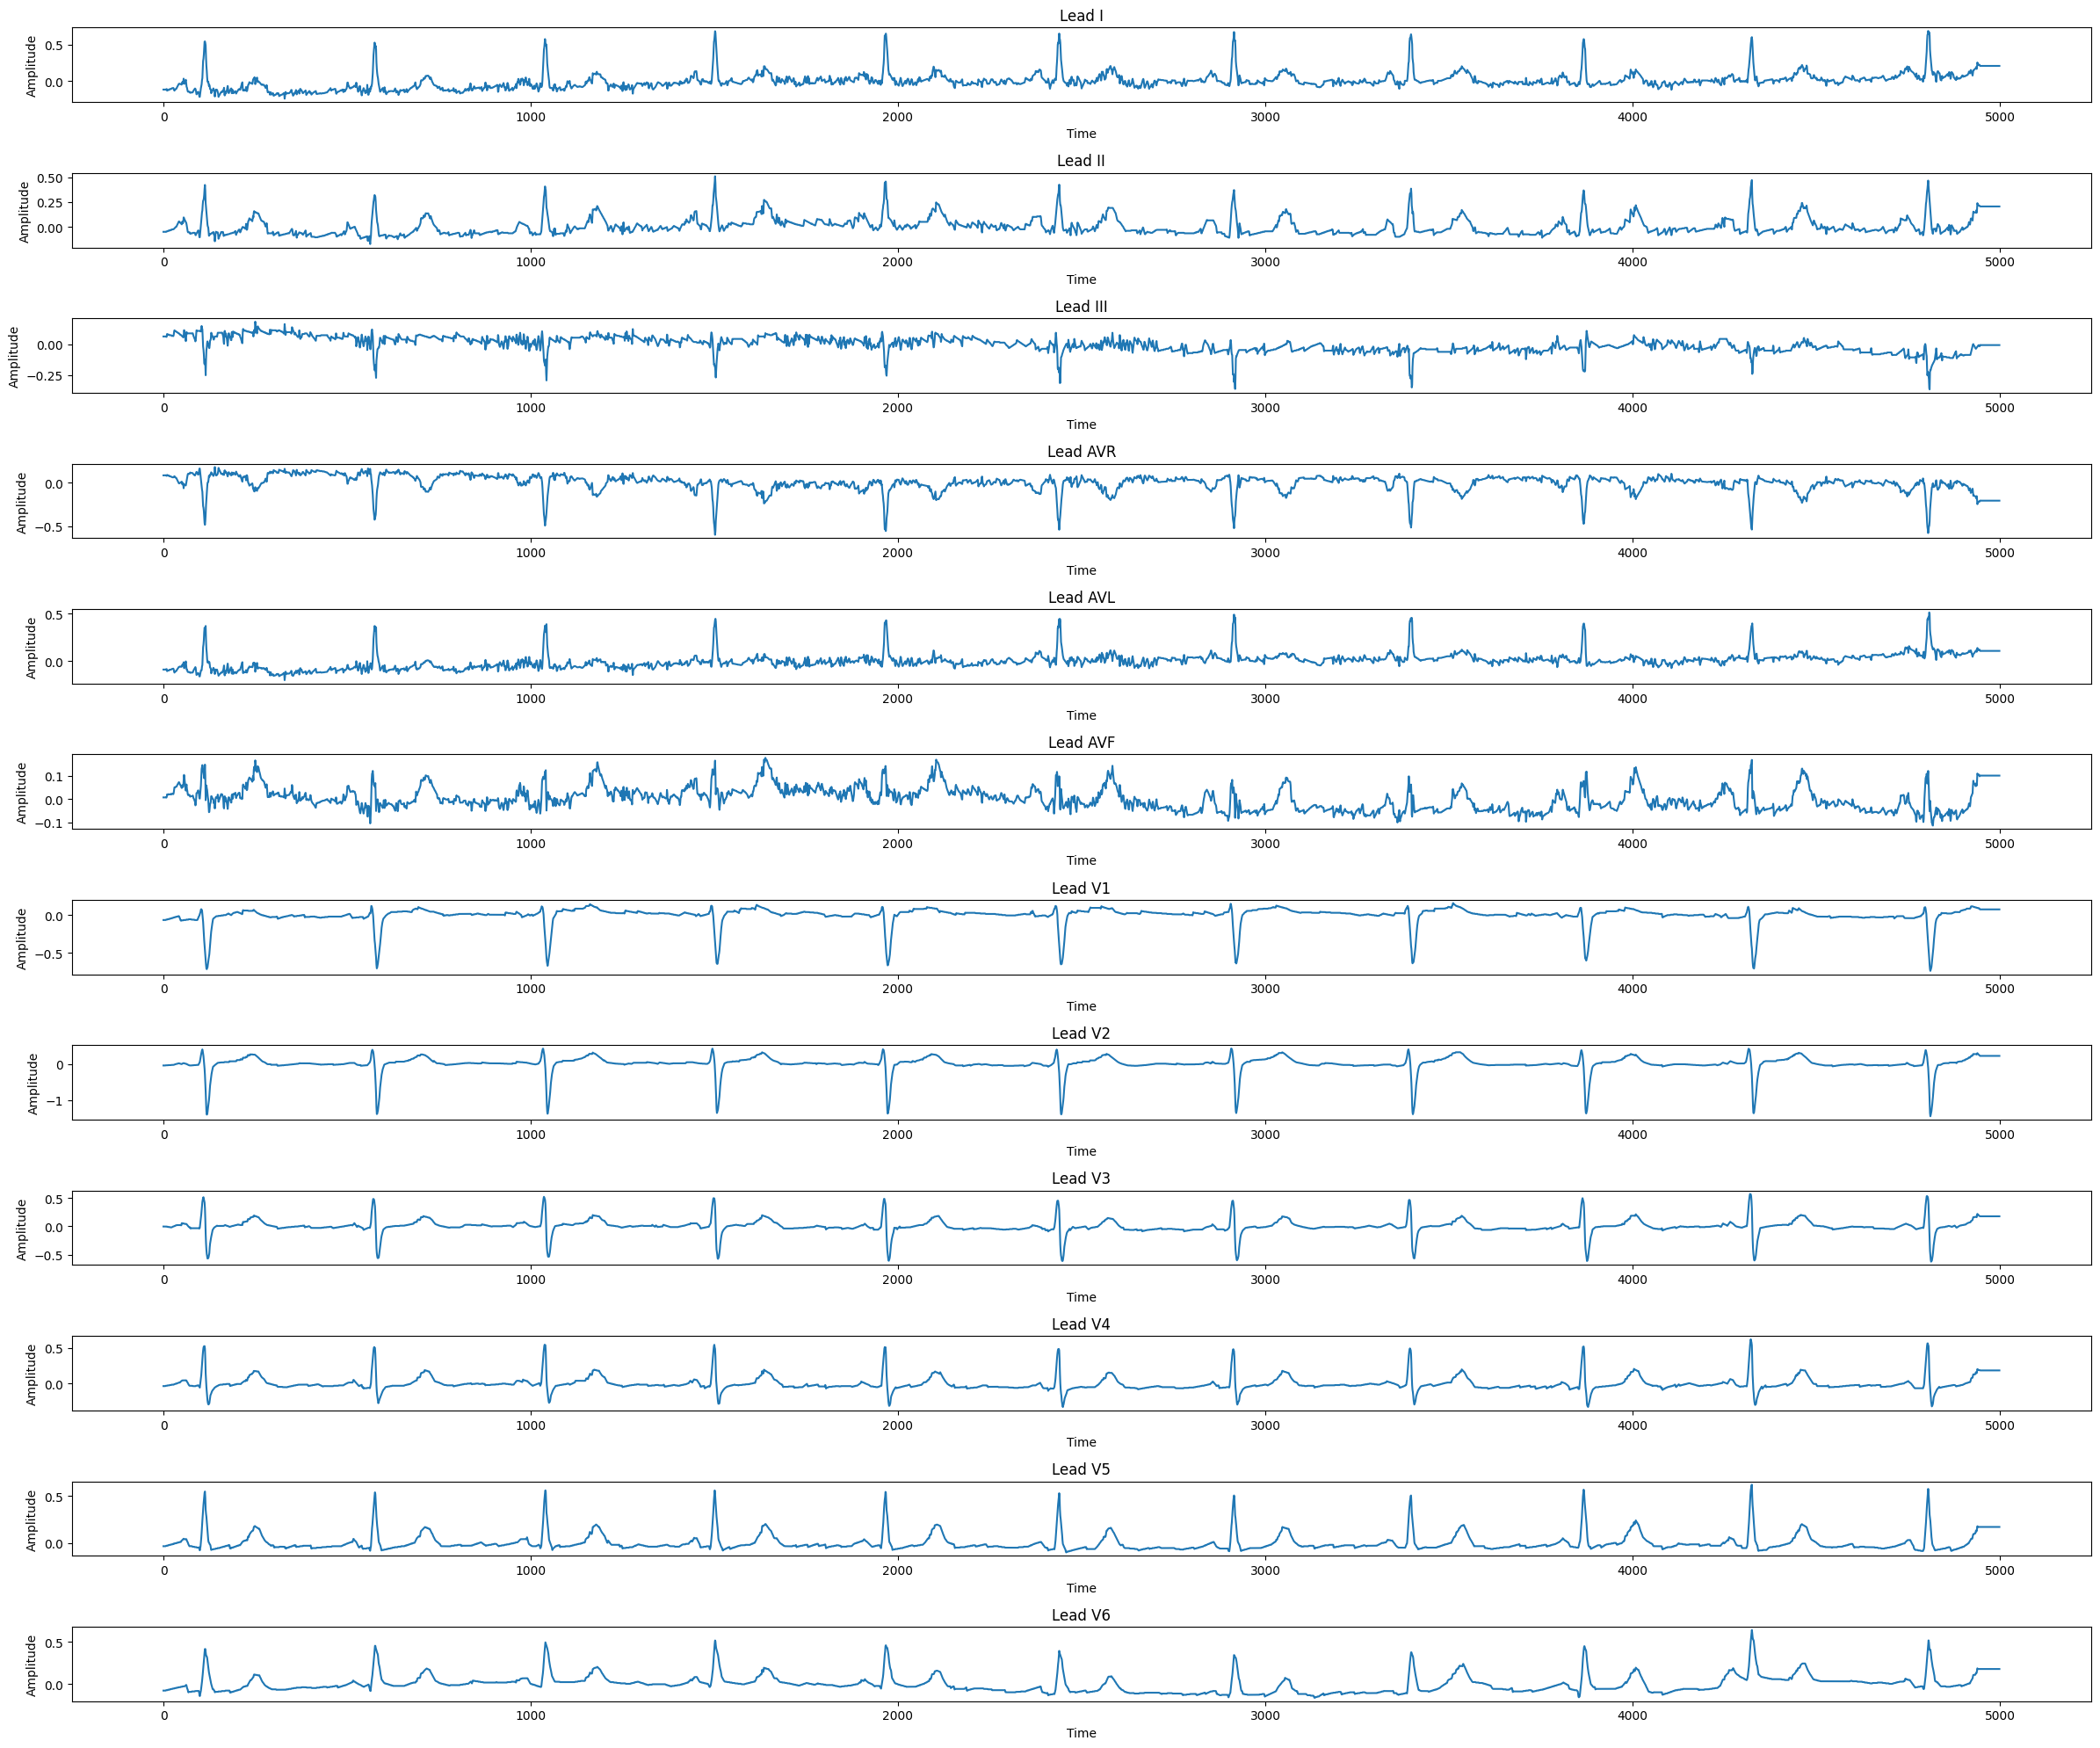

In [26]:
import matplotlib.pyplot as plt

for j in range(1):
    plt.figure(figsize=(24, 20))
    # Plot first 12 leads
    for i in range(12):
        plt.subplot(12, 1, i + 1)
        # plt.plot(signals[j][:, i])
        plt.plot(signals[j][:, i])
        plt.title(f"Lead {leads_names[j][i]}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

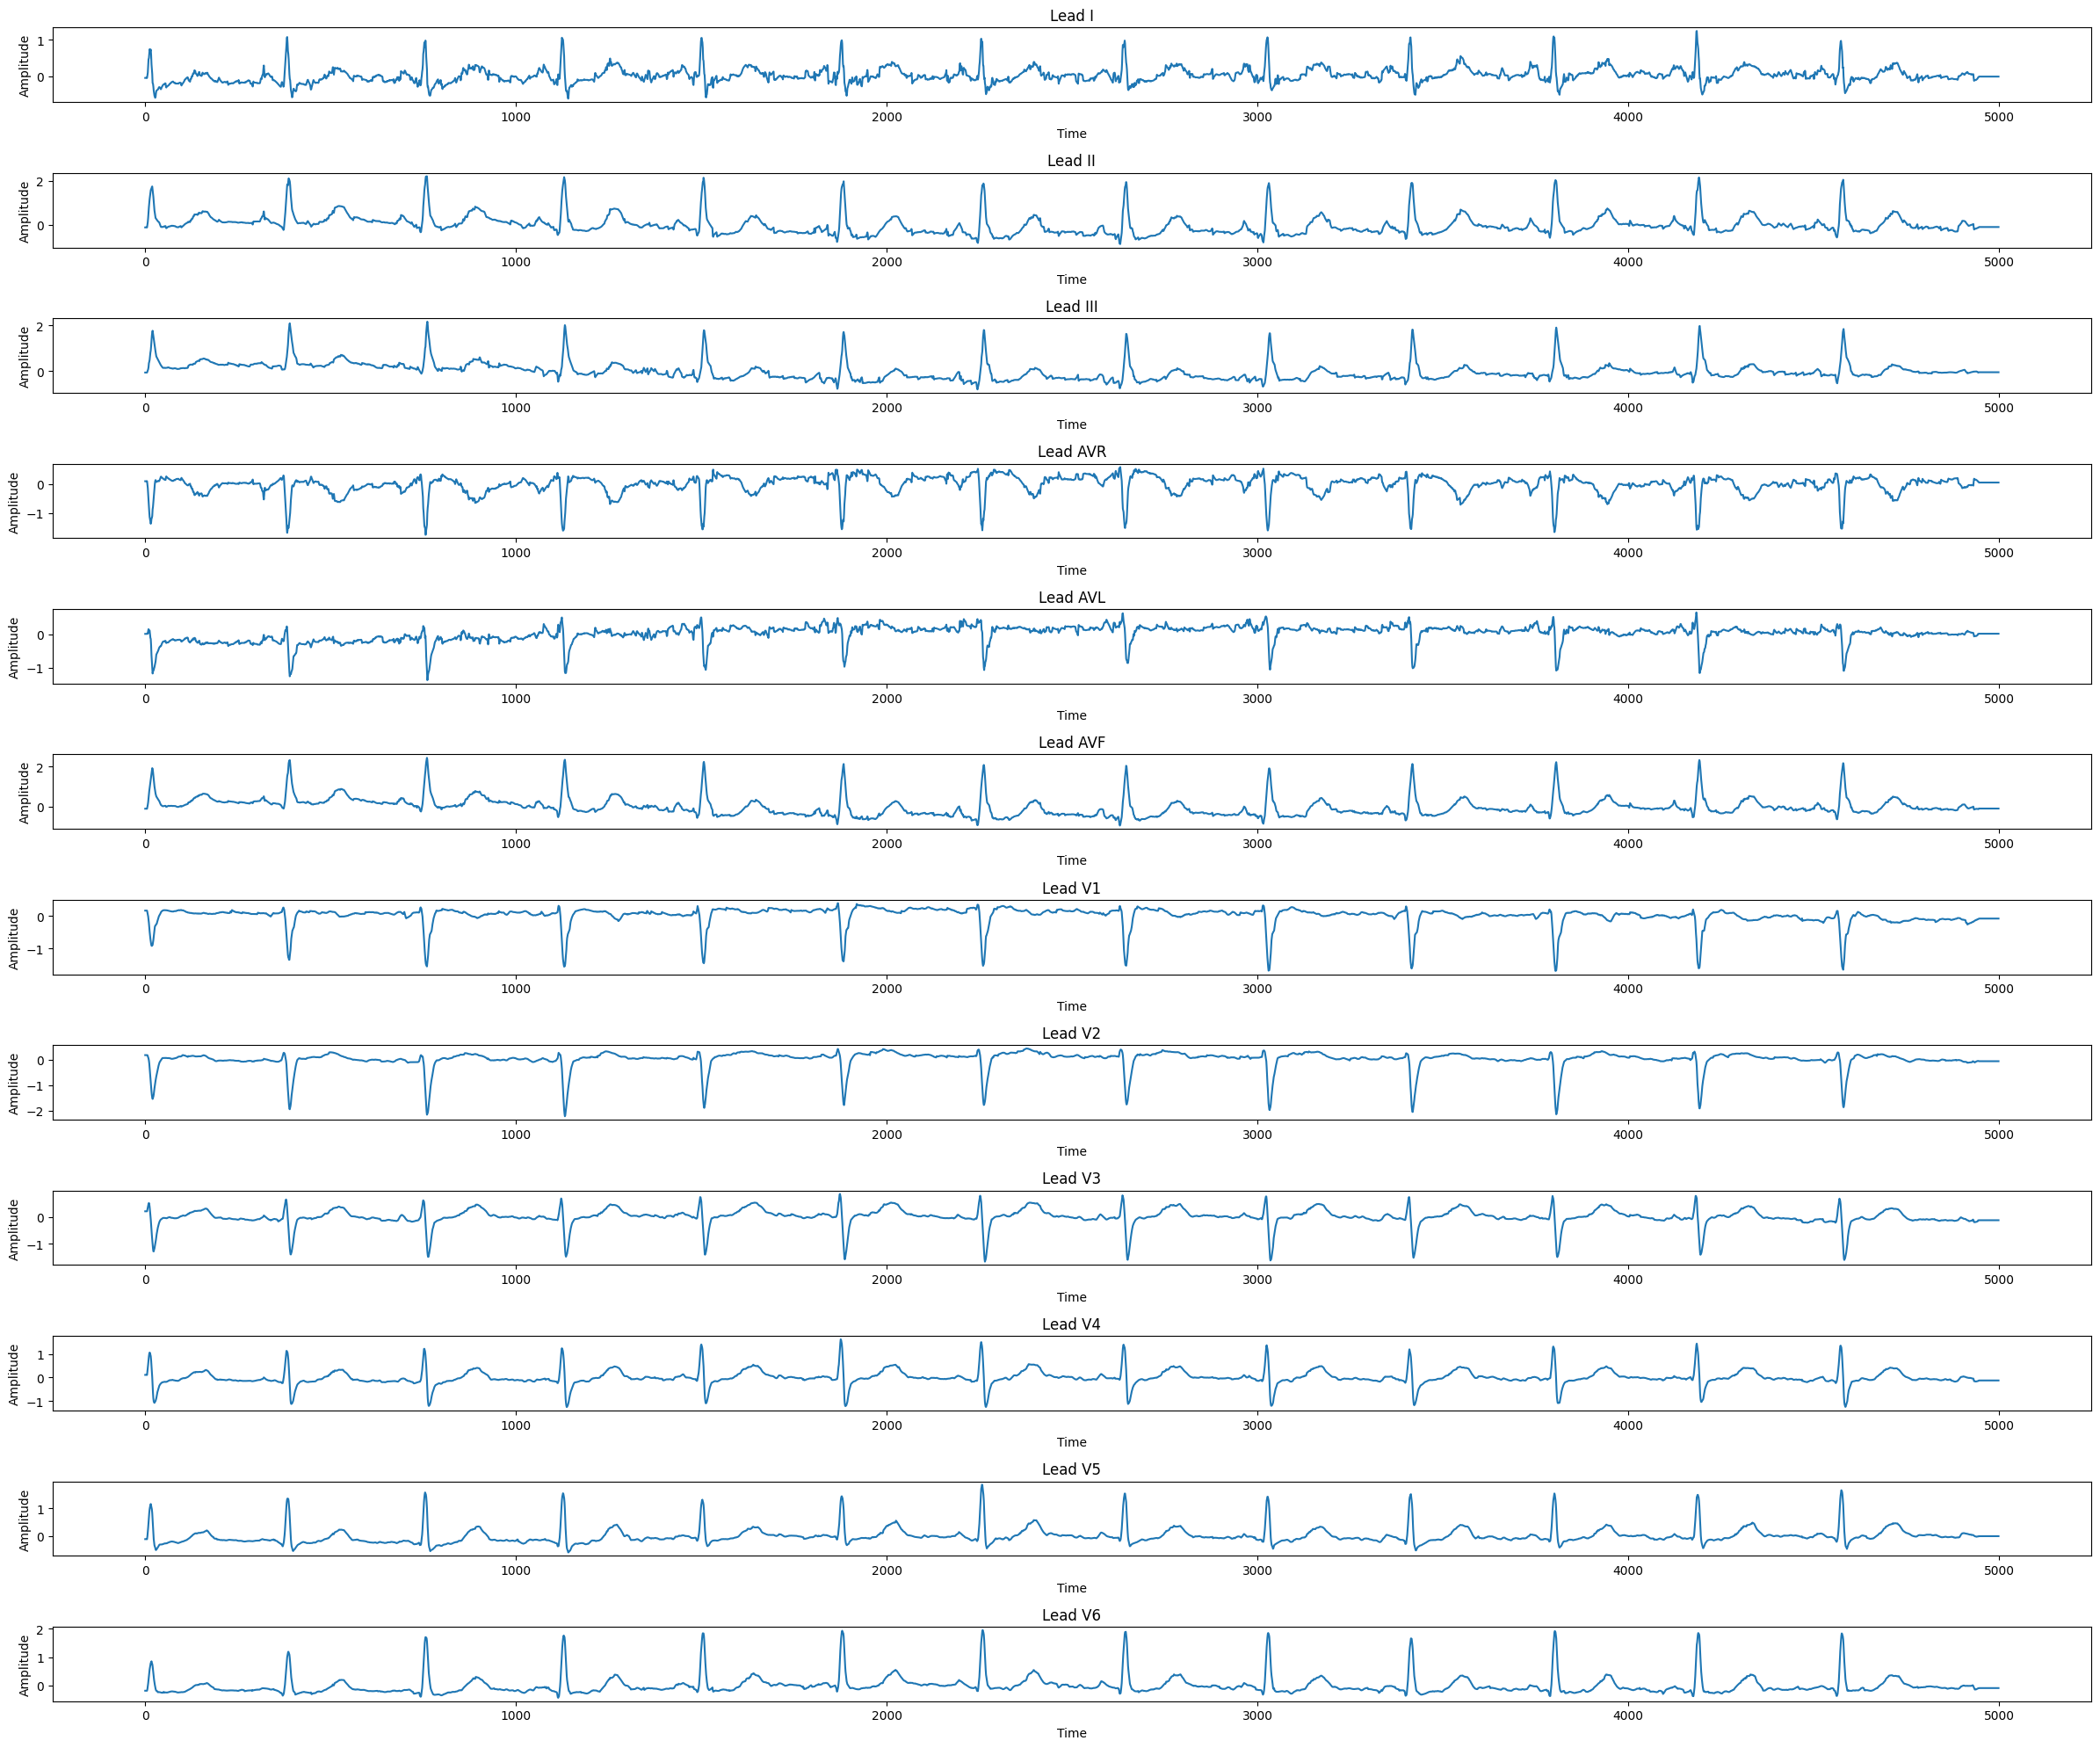

In [27]:
import matplotlib.pyplot as plt

for j in range(1):
    plt.figure(figsize=(24, 20))
    # Plot first 12 leads
    for i in range(12):
        plt.subplot(12, 1, i + 1)
        # plt.plot(signals[j][:, i])
        plt.plot(preprocessed_signals[j][:, i])
        plt.title(f"Lead {leads_names[j][i]}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

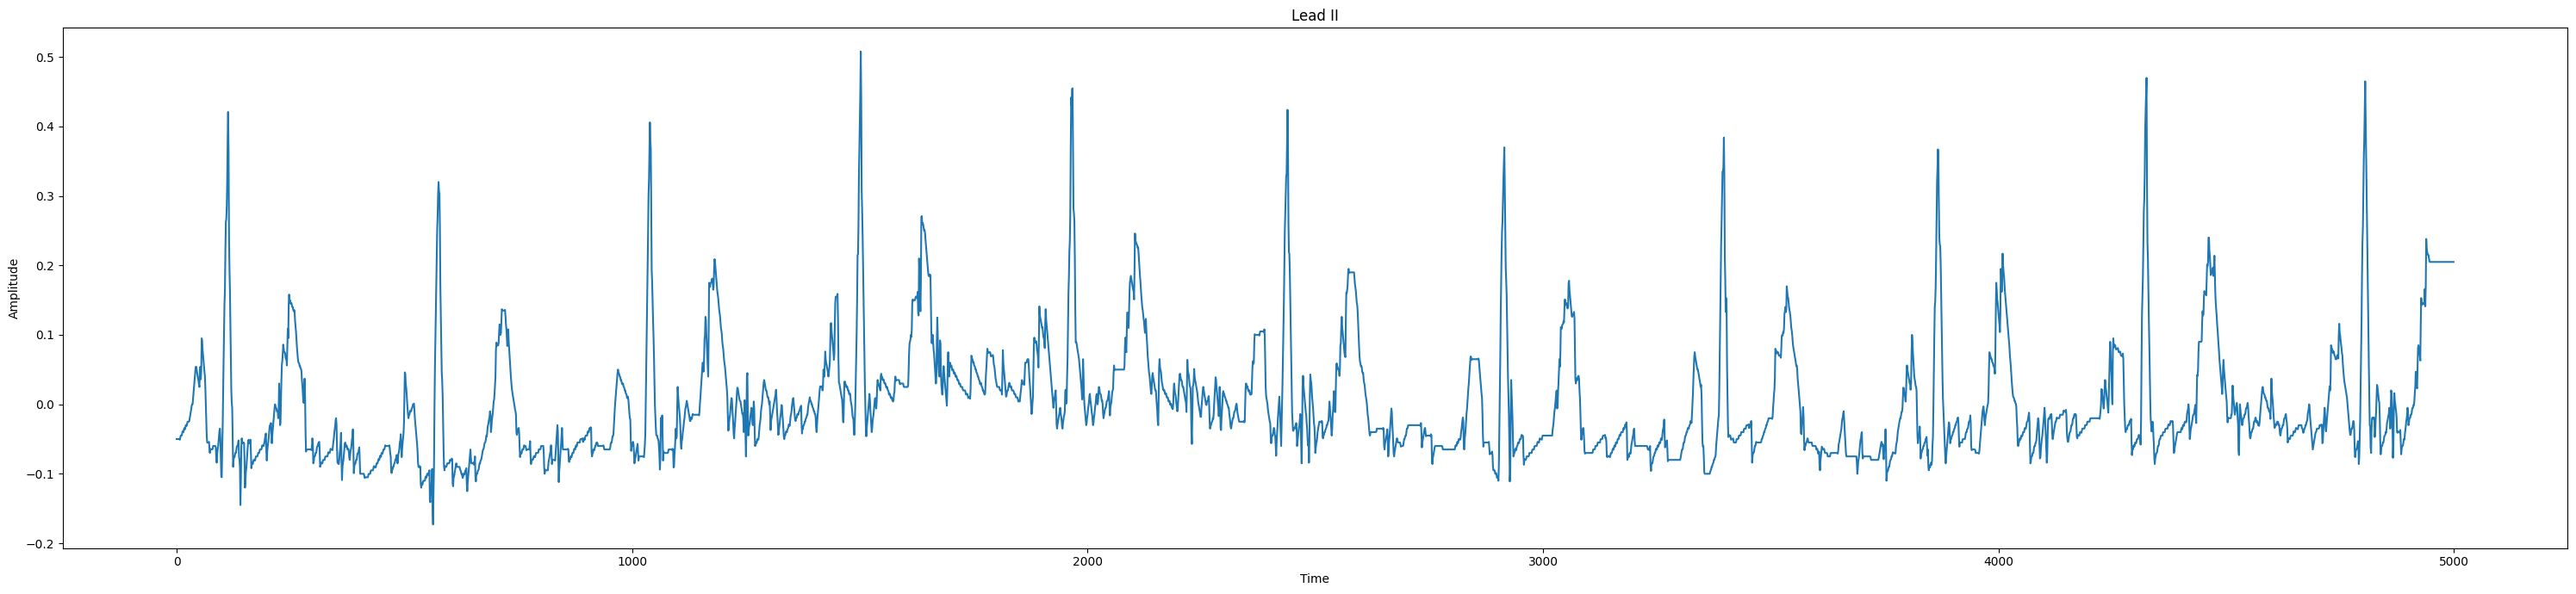

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 7))
plt.plot(signals[0][:, 1])
plt.title(f"Lead {leads_names[0][1]}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

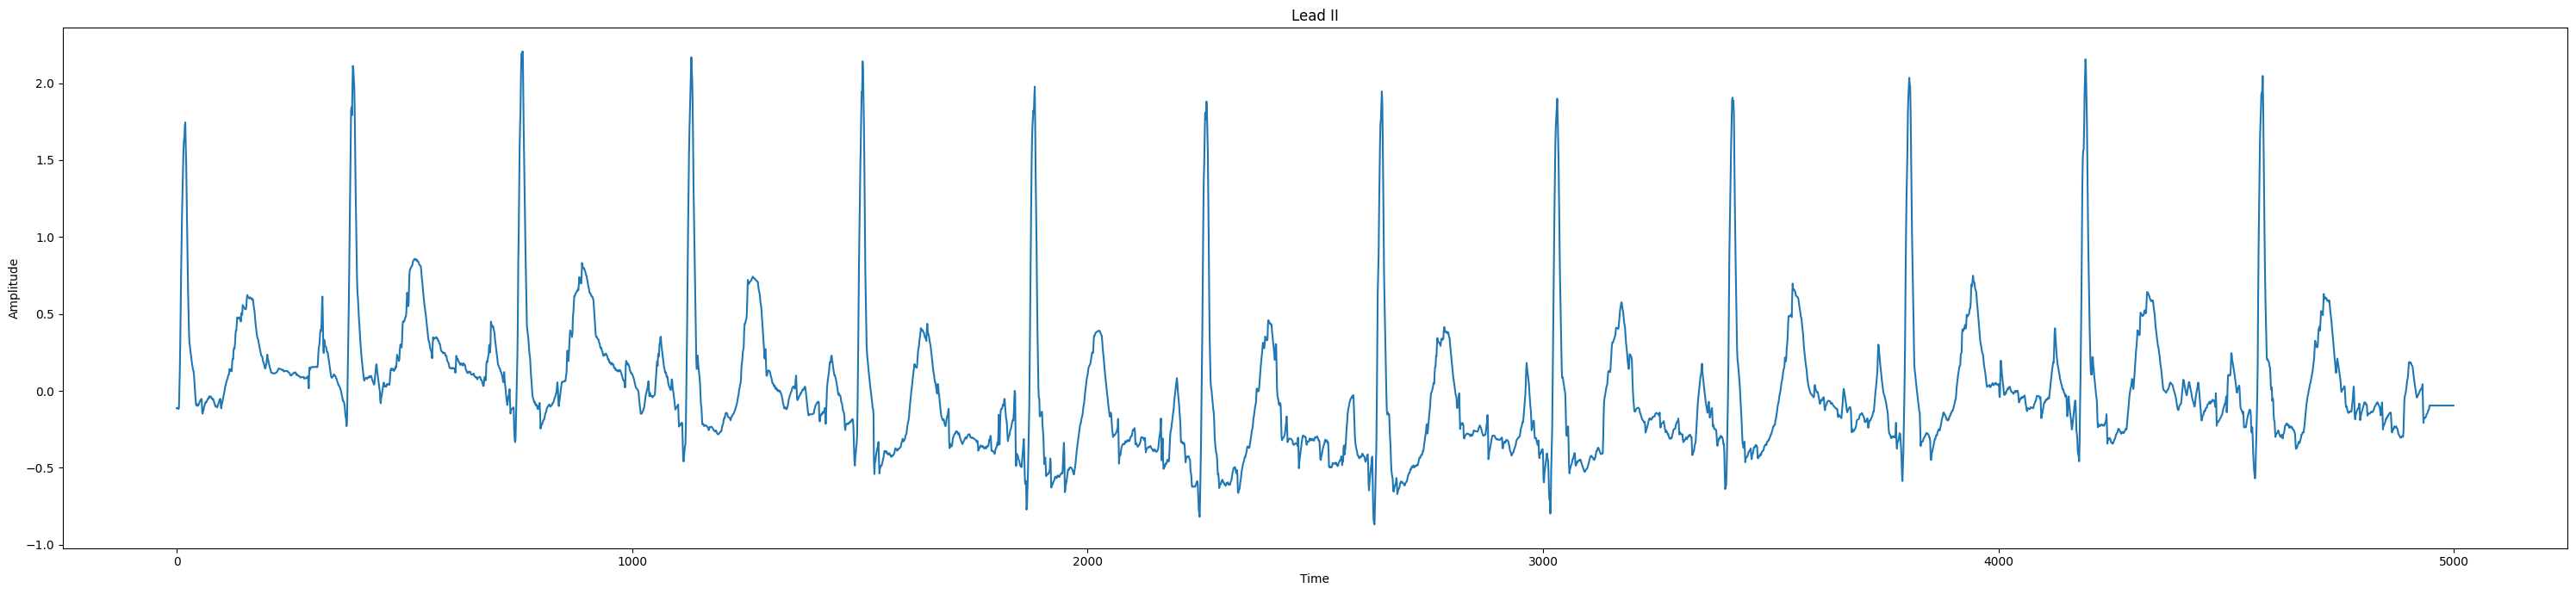

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 7))
plt.plot(preprocessed_signals[0][:, 1])
plt.title(f"Lead {leads_names[0][1]}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()